In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = {
    'Area': [500, 700, 900, 1100, 1300, 1500, 1700, 1900, 2100, 2300],
    'Price': [25, 32, 40, 48, 55, 65, 72, 82, 90, 100]
}

df = pd.DataFrame(data)

print(df)

   Area  Price
0   500     25
1   700     32
2   900     40
3  1100     48
4  1300     55
5  1500     65
6  1700     72
7  1900     82
8  2100     90
9  2300    100


In [3]:
X = df['Area'].values
Y = df['Price'].values

In [4]:
X_gd = X / 1000

In [5]:
Y_gd = Y

In [6]:
print("X:", X_gd)
print("Y:", Y_gd)

X: [0.5 0.7 0.9 1.1 1.3 1.5 1.7 1.9 2.1 2.3]
Y: [ 25  32  40  48  55  65  72  82  90 100]


In [7]:
m = 0
c = 0

learning_rate = 0.01
epochs = 1000

n = len(X_gd)

cost_history = []

In [8]:
for i in range(epochs):

    # Step 1: Calculate prediction
    Y_pred = m * X_gd + c

    # Step 2: Calculate error
    error = Y_pred - Y_gd

    # Step 3: Calculate cost
    cost = (1/(2*n)) * np.sum(error**2)

    # Store cost
    cost_history.append(cost)

    # Step 4: Calculate gradients
    dm = (1/n) * np.sum(error * X_gd)
    dc = (1/n) * np.sum(error)

    # Step 5: Update parameters
    m = m - learning_rate * dm
    c = c - learning_rate * dc

In [9]:
print("Final slope (m):", m)
print("Final intercept (c):", c)

Final slope (m): 37.74074656591996
Final intercept (c): 8.688130752421099


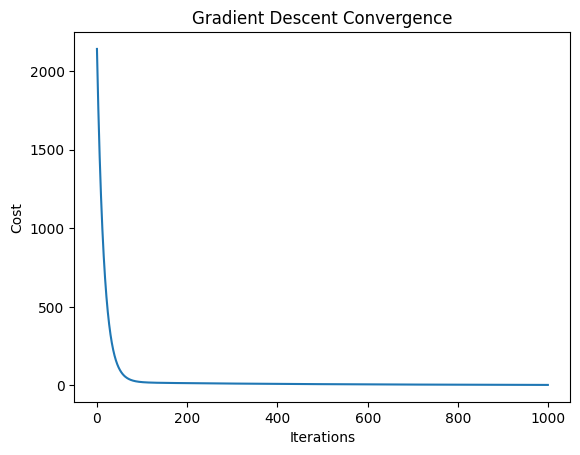

In [10]:
# Cost vs Iterations

plt.plot(cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")

plt.show()

In [11]:
# Predictions

Y_pred_gd = m * X_gd + c

print(Y_pred_gd)

[27.55850404 35.10665335 42.65480266 50.20295197 57.75110129 65.2992506
 72.84739991 80.39554923 87.94369854 95.49184785]


In [12]:
# Comparison

comparison = pd.DataFrame({
    'Area': X,
    'Actual Price': Y,
    'Predicted Price': Y_pred_gd
})

print(comparison)

   Area  Actual Price  Predicted Price
0   500            25        27.558504
1   700            32        35.106653
2   900            40        42.654803
3  1100            48        50.202952
4  1300            55        57.751101
5  1500            65        65.299251
6  1700            72        72.847400
7  1900            82        80.395549
8  2100            90        87.943699
9  2300           100        95.491848


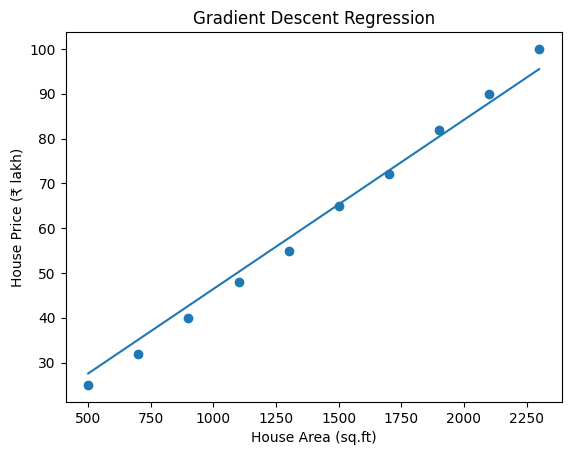

In [13]:
# Regression line

plt.scatter(X, Y)
plt.plot(X, Y_pred_gd)

plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price (₹ lakh)")
plt.title("Gradient Descent Regression")

plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [16]:
# Evaluation

MAE = mean_absolute_error(Y, Y_pred_gd)
MSE = mean_squared_error(Y, Y_pred_gd)
RMSE = np.sqrt(MSE)
R2 = r2_score(Y, Y_pred_gd)

print("MAE =", MAE)
print("MSE =", MSE)
print("RMSE =", RMSE)
print("R2 Score =", R2)

MAE = 2.258956820197236
MSE = 6.3600482081705065
RMSE = 2.5219136004571028
R2 Score = 0.9888866689822109
